<a href="https://colab.research.google.com/github/KunalSoyane/EDA-Portfolio/blob/main/EDA_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA Portfolio — Kunal Vivek Soyane
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KunalSoyane/EDA-Portfolio/blob/main/EDA_Portfolio.ipynb)

Structured exploratory data analysis across three real-world domains.

Each dataset runs through a consistent pipeline built on the reusable `EDAAnalyser` class:

> missing value analysis → imputation → outlier detection (IQR + Z-score) → distributions → skewness → correlation heatmap → VIF (multicollinearity) → pair plots

| # | Domain | Dataset | Rows | Features | Target |
|---|--------|---------|------|----------|--------|
| 1 | Health | Pima Indians Diabetes | 768 | 8 | Outcome (diabetes) |
| 2 | Financial | Synthetic Loan Applications | 1,000 | 7 | loan_approved |
| 3 | Retail | Synthetic Transactions | 900 | 6 | return_flag |

**Stack:** Python · pandas · NumPy · matplotlib · seaborn · scipy · statsmodels


## Setup

In [10]:
# ============================================================
# SETUP
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#f8f9fa',
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'font.size':          10,
})

print("Environment ready.")


Environment ready.


## Reusable EDA Pipeline

In [11]:
# ============================================================
# REUSABLE EDA PIPELINE — EDAAnalyser
# ============================================================
# Usage:
#   eda = EDAAnalyser(df, name='Loan Data', target='approved')
#   eda.overview()
#   eda.missing_report()
#   eda.impute(strategy='median')
#   eda.outlier_iqr()
#   eda.outlier_zscore()
#   eda.distribution()
#   eda.skewness_report()
#   eda.correlation_heatmap()
#   eda.vif_report()
#   eda.pairplot(hue='approved')
# ============================================================

class EDAAnalyser:

    PALETTE = ['#1A56DB', '#E24B4A', '#1D9E75', '#F59E0B', '#8B5CF6']

    def __init__(self, df, name, target=None):
        self.df     = df.copy()
        self.name   = name
        self.target = target
        self._num   = [c for c in df.select_dtypes(include=np.number).columns
                       if c != target]
        self._cat   = df.select_dtypes(include='object').columns.tolist()
        print(f"\n{'='*55}")
        print(f"  EDAAnalyser  —  {self.name}")
        print(f"{'='*55}")
        print(f"  Rows       : {df.shape[0]}")
        print(f"  Columns    : {df.shape[1]}")
        print(f"  Numeric    : {self._num}")
        print(f"  Categorical: {self._cat}")
        print(f"  Target     : {target}")

    def overview(self):
        # Dtypes, null counts, descriptive statistics
        print(f"\n--- Overview: {self.name} ---")
        info             = self.df.dtypes.to_frame('dtype')
        info['nulls']    = self.df.isnull().sum()
        info['null_pct'] = (self.df.isnull().mean() * 100).round(2)
        print(info.to_string())
        print("\nDescriptive Statistics (numeric):")
        print(self.df[self._num].describe().round(3).T.to_string())
        return self

    def missing_report(self, plot=True):
        # Quantify missing values; optionally plot bar chart and pattern heatmap
        nulls = self.df.isnull().sum()
        nulls = nulls[nulls > 0]

        if nulls.empty:
            print(f"\nNo missing values in {self.name}.")
            return self

        print(f"\n--- Missing Values: {self.name} ---")
        report = pd.DataFrame({
            'count': nulls,
            'pct':   (nulls / len(self.df) * 100).round(2),
        }).sort_values('pct', ascending=False)
        print(report.to_string())

        if plot:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            fig.suptitle(f'Missing Values — {self.name}', fontweight='bold')
            report['pct'].sort_values().plot(
                kind='barh', ax=axes[0],
                color=self.PALETTE[0], edgecolor='white'
            )
            axes[0].set_xlabel('Missing (%)')
            axes[0].set_title('Missing Percentage by Column')
            sns.heatmap(
                self.df[nulls.index].isnull(), ax=axes[1],
                cbar=False, yticklabels=False, cmap='binary'
            )
            axes[1].set_title('Missing Pattern  (white = missing)')
            plt.tight_layout()
            plt.show()
        return self

    def impute(self, strategy='median', cols=None):
        # Impute missing values in-place. strategy: 'median' | 'mean' | 'mode'
        cols = cols or self._num
        print(f"\n--- Imputation ({strategy}): {self.name} ---")
        for col in cols:
            if self.df[col].isnull().any():
                val = (self.df[col].median() if strategy == 'median'
                       else self.df[col].mean() if strategy == 'mean'
                       else self.df[col].mode()[0])
                self.df[col].fillna(val, inplace=True)
                print(f"  {col:25s}  fill value = {round(val, 4)}")
        return self

    def outlier_iqr(self, cols=None, cap=False):
        # IQR-based outlier detection with boxplots.
        # cap=True applies Winsorisation (clips at fence boundaries).
        cols = cols or self._num
        print(f"\n--- Outlier Detection (IQR): {self.name} ---")

        rows = []
        for col in cols:
            q1, q3 = self.df[col].quantile([0.25, 0.75])
            iqr    = q3 - q1
            lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            n_out  = ((self.df[col] < lo) | (self.df[col] > hi)).sum()
            rows.append({
                'feature':     col,
                'Q1':          round(q1, 2),
                'Q3':          round(q3, 2),
                'IQR':         round(iqr, 2),
                'lower_fence': round(lo, 2),
                'upper_fence': round(hi, 2),
                'outliers':    n_out,
                'outlier_pct': round(n_out / len(self.df) * 100, 2),
            })
            if cap and n_out > 0:
                self.df[col] = self.df[col].clip(lo, hi)

        result  = pd.DataFrame(rows).set_index('feature')
        flagged = result[result['outliers'] > 0]
        print(flagged.to_string() if not flagged.empty else "  No outliers detected.")

        n = len(cols)
        fig, axes = plt.subplots(1, n, figsize=(max(3.5 * n, 8), 4))
        if n == 1:
            axes = [axes]
        fig.suptitle(f'Outlier Boxplots (IQR) — {self.name}', fontweight='bold')
        for ax, col in zip(axes, cols):
            self.df.boxplot(
                column=col, ax=ax,
                boxprops=dict(color=self.PALETTE[0]),
                medianprops=dict(color=self.PALETTE[1], linewidth=2),
                flierprops=dict(marker='o', color=self.PALETTE[1],
                                markersize=4, alpha=0.5)
            )
            ax.set_title(col, fontsize=9)
            ax.set_xlabel('')
        plt.tight_layout()
        plt.show()
        return self

    def outlier_zscore(self, cols=None, threshold=3.0):
        # Flag rows where |Z-score| exceeds threshold
        cols = cols or self._num
        print(f"\n--- Outlier Detection (Z-score, |z|>{threshold}): {self.name} ---")
        any_found = False
        for col in cols:
            z = np.abs(stats.zscore(self.df[col].dropna()))
            n = (z > threshold).sum()
            if n > 0:
                print(f"  {col:25s}: {n} flagged  ({n / len(self.df) * 100:.2f}%)")
                any_found = True
        if not any_found:
            print("  No outliers detected at this threshold.")
        return self

    def distribution(self, cols=None):
        # Histogram + KDE overlay with skewness annotation
        cols  = cols or self._num
        n     = len(cols)
        ncols = min(3, n)
        nrows = (n + ncols - 1) // ncols

        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
        axes = np.array(axes).flatten()
        fig.suptitle(f'Feature Distributions — {self.name}', fontweight='bold', y=1.01)

        for ax, col in zip(axes, cols):
            data = self.df[col].dropna()
            ax.hist(data, bins=30, color=self.PALETTE[0],
                    edgecolor='white', alpha=0.75, density=True)
            data.plot.kde(ax=ax, color=self.PALETTE[1], linewidth=2)
            skew = data.skew()
            ax.set_title(col, fontsize=9)
            ax.set_xlabel('')
            ax.text(0.97, 0.95, f'skew={skew:.2f}',
                    transform=ax.transAxes, ha='right', va='top',
                    fontsize=8, color='gray')

        for ax in axes[n:]:
            ax.set_visible(False)

        plt.tight_layout()
        plt.show()
        return self

    def skewness_report(self):
        # Report skewness with interpretation for each numeric feature
        print(f"\n--- Skewness Report: {self.name} ---")

        def interpret(s):
            if abs(s) < 0.5:  return 'symmetric'
            if abs(s) < 1.0:  return 'moderate skew'
            return 'high skew  (consider log/sqrt transform)'

        skew = self.df[self._num].skew().round(3).sort_values(key=abs, ascending=False)
        report = pd.DataFrame({
            'skewness':      skew,
            'interpretation': skew.map(interpret),
        })
        print(report.to_string())
        return self

    def correlation_heatmap(self):
        # Lower-triangle Pearson correlation heatmap + high-correlation flag
        corr = self.df[self._num].corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))
        size = max(6, len(self._num))

        fig, ax = plt.subplots(figsize=(size, size - 1))
        sns.heatmap(
            corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax
        )
        ax.set_title(f'Pearson Correlation — {self.name}', fontweight='bold')
        plt.tight_layout()
        plt.show()

        high = [
            (i, j, round(corr.loc[i, j], 3))
            for i in corr.columns for j in corr.columns
            if i < j and abs(corr.loc[i, j]) > 0.75
        ]
        if high:
            print("Pairs with |r| > 0.75:")
            for i, j, r in high:
                print(f"  {i}  <->  {j}:  r = {r}")
        return self

    def vif_report(self, cols=None):
        # Variance Inflation Factor for multicollinearity detection.
        # VIF > 10 : high multicollinearity
        # VIF > 5  : moderate concern
        cols = cols or self._num
        if len(cols) < 2:
            print("VIF requires at least 2 features.")
            return self

        X = self.df[cols].dropna()
        vif = pd.DataFrame({
            'feature': cols,
            'VIF':     [variance_inflation_factor(X.values, i)
                        for i in range(len(cols))]
        }).set_index('feature').sort_values('VIF', ascending=False)

        vif['status'] = vif['VIF'].apply(
            lambda v: 'HIGH — multicollinear' if v > 10
            else ('moderate'                   if v > 5
            else  'OK')
        )
        print(f"\n--- VIF Analysis: {self.name} ---")
        print(vif.round(2).to_string())
        return self

    def pairplot(self, cols=None, hue=None):
        # Seaborn pairplot for selected numeric features
        cols    = cols or self._num[:5]
        hue_col = [hue] if (hue and hue in self.df.columns) else []
        plot_df = self.df[cols + hue_col].dropna()

        kws = {}
        if hue:
            kws['palette'] = self.PALETTE[:plot_df[hue].nunique()]

        g = sns.pairplot(
            plot_df, hue=hue, diag_kind='kde',
            plot_kws={'alpha': 0.45, 's': 18}, **kws
        )
        g.fig.suptitle(f'Pair Plot — {self.name}', y=1.02, fontweight='bold')
        plt.tight_layout()
        plt.show()
        return self


print("EDAAnalyser class ready.")


EDAAnalyser class ready.


---
## Dataset 1 — Health
### Pima Indians Diabetes

**Source:** UCI Machine Learning Repository / Jason Brownlee  
**Task:** Predict onset of diabetes based on diagnostic measurements  
**Key challenge:** Missing values encoded as physiological zeros (Glucose, Insulin, BMI, etc.)


Loaded: 768 rows x 9 columns
Class distribution:
Outcome
0    500
1    268

  EDAAnalyser  —  Pima Diabetes  [Health]
  Rows       : 768
  Columns    : 9
  Numeric    : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age']
  Categorical: []
  Target     : Outcome

--- Overview: Pima Diabetes  [Health] ---
                    dtype  nulls  null_pct
Pregnancies         int64      0      0.00
Glucose           float64      5      0.65
BloodPressure     float64     35      4.56
SkinThickness     float64    227     29.56
Insulin           float64    374     48.70
BMI               float64     11      1.43
DiabetesPedigree  float64      0      0.00
Age                 int64      0      0.00
Outcome             int64      0      0.00

Descriptive Statistics (numeric):
                  count     mean      std     min     25%      50%      75%     max
Pregnancies       768.0    3.845    3.370   0.000   1.000    3.000    6.000   17.00
Glucose 

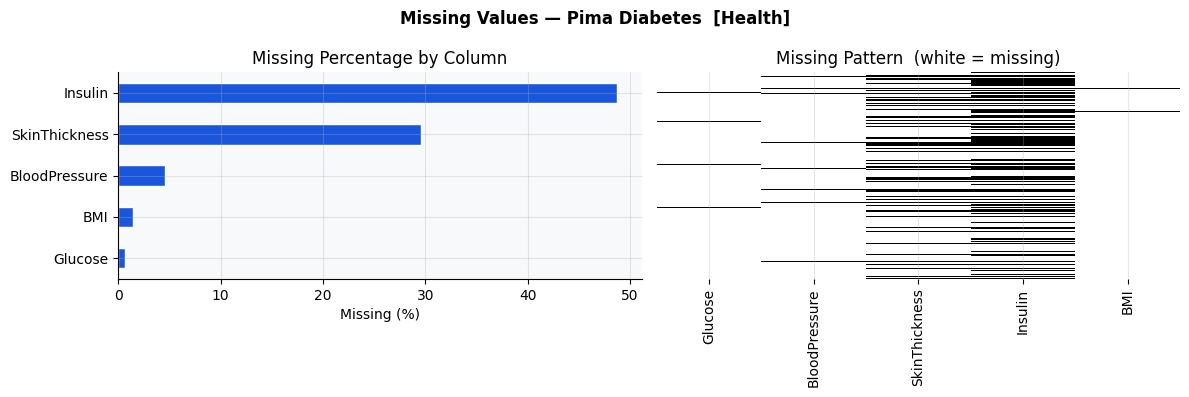


--- Imputation (median): Pima Diabetes  [Health] ---
  Glucose                    fill value = 117.0
  BloodPressure              fill value = 72.0
  SkinThickness              fill value = 29.0
  Insulin                    fill value = 125.0
  BMI                        fill value = 32.3

--- Outlier Detection (IQR): Pima Diabetes  [Health] ---
                  Q1      Q3    IQR  lower_fence  upper_fence  outliers  outlier_pct
feature                                                                             
BloodPressure   64.0   80.00  16.00        40.00       104.00        14         1.82
BMI             27.5   36.60   9.10        13.85        50.25         8         1.04
Insulin        121.5  127.25   5.75       112.88       135.88       346        45.05
Age             24.0   41.00  17.00        -1.50        66.50         9         1.17


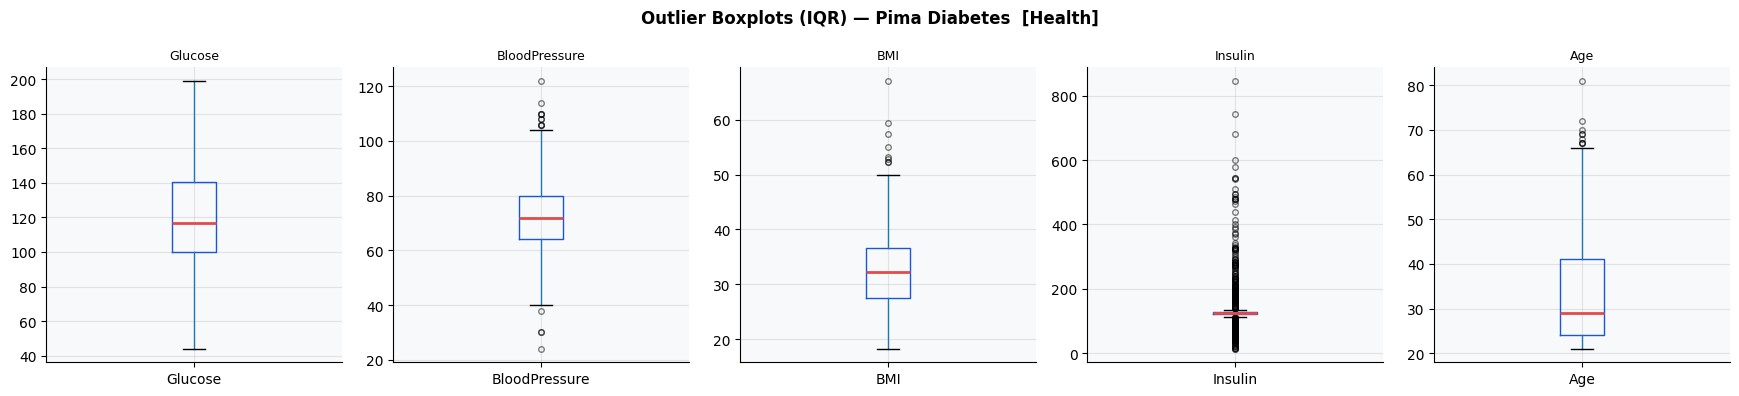


--- Outlier Detection (Z-score, |z|>3.0): Pima Diabetes  [Health] ---
  Pregnancies              : 4 flagged  (0.52%)
  BloodPressure            : 8 flagged  (1.04%)
  SkinThickness            : 4 flagged  (0.52%)
  Insulin                  : 20 flagged  (2.60%)
  BMI                      : 5 flagged  (0.65%)
  DiabetesPedigree         : 11 flagged  (1.43%)
  Age                      : 5 flagged  (0.65%)


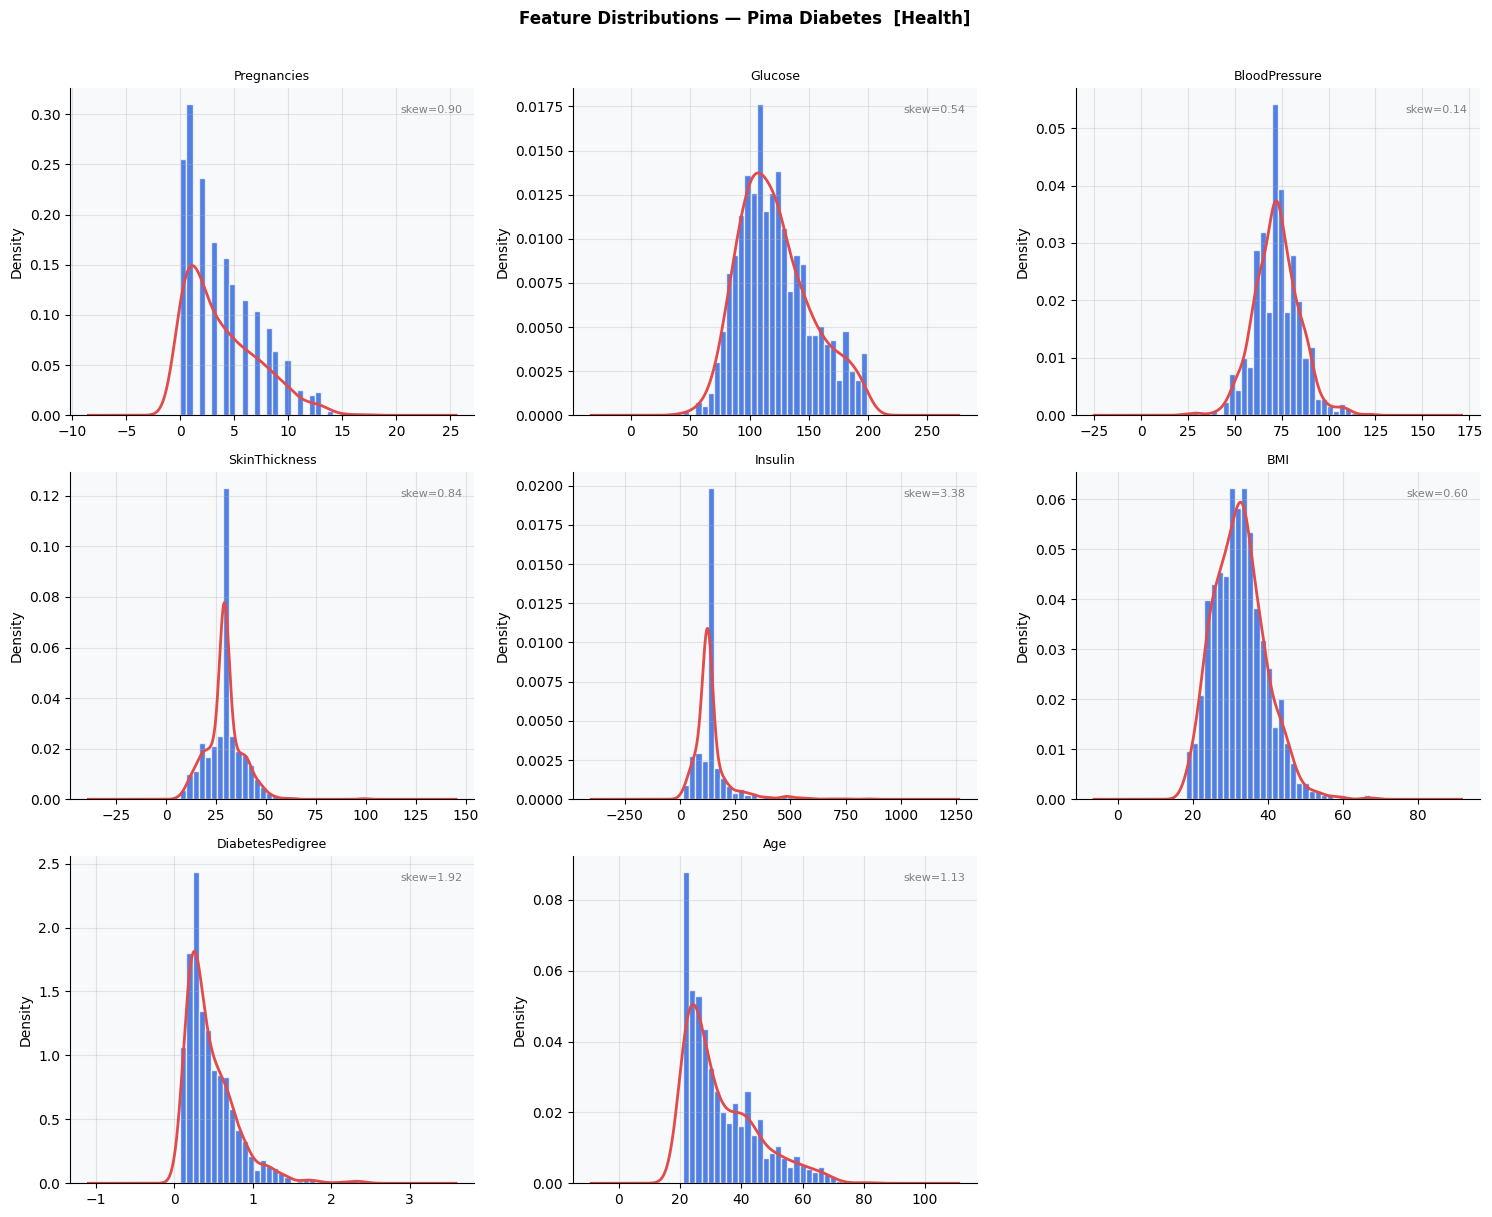


--- Skewness Report: Pima Diabetes  [Health] ---
                  skewness                            interpretation
Insulin              3.380  high skew  (consider log/sqrt transform)
DiabetesPedigree     1.920  high skew  (consider log/sqrt transform)
Age                  1.130  high skew  (consider log/sqrt transform)
Pregnancies          0.902                             moderate skew
SkinThickness        0.838                             moderate skew
BMI                  0.599                             moderate skew
Glucose              0.536                             moderate skew
BloodPressure        0.142                                 symmetric


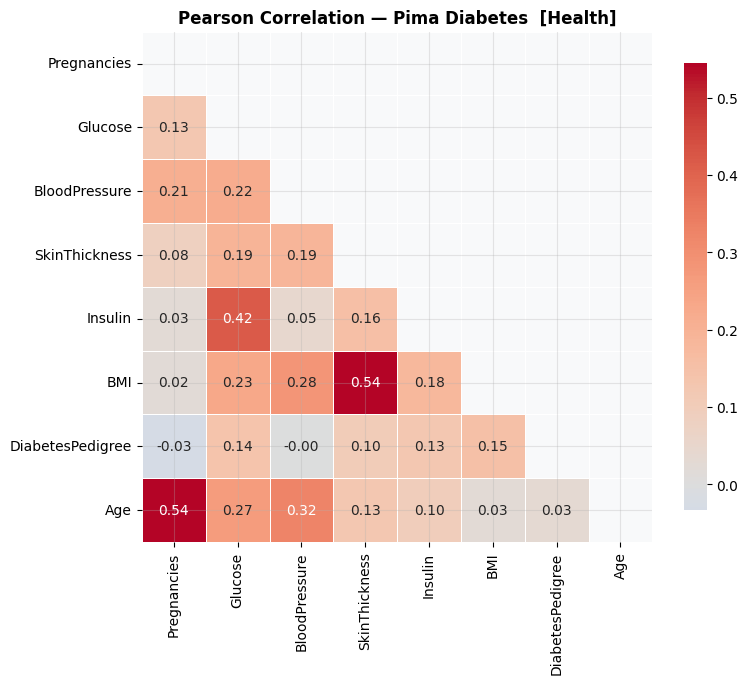


--- VIF Analysis: Pima Diabetes  [Health] ---
                    VIF                 status
feature                                       
BMI               33.68  HIGH — multicollinear
BloodPressure     31.72  HIGH — multicollinear
Glucose           21.72  HIGH — multicollinear
SkinThickness     17.32  HIGH — multicollinear
Age               14.36  HIGH — multicollinear
Insulin            4.53                     OK
Pregnancies        3.27                     OK
DiabetesPedigree   3.15                     OK


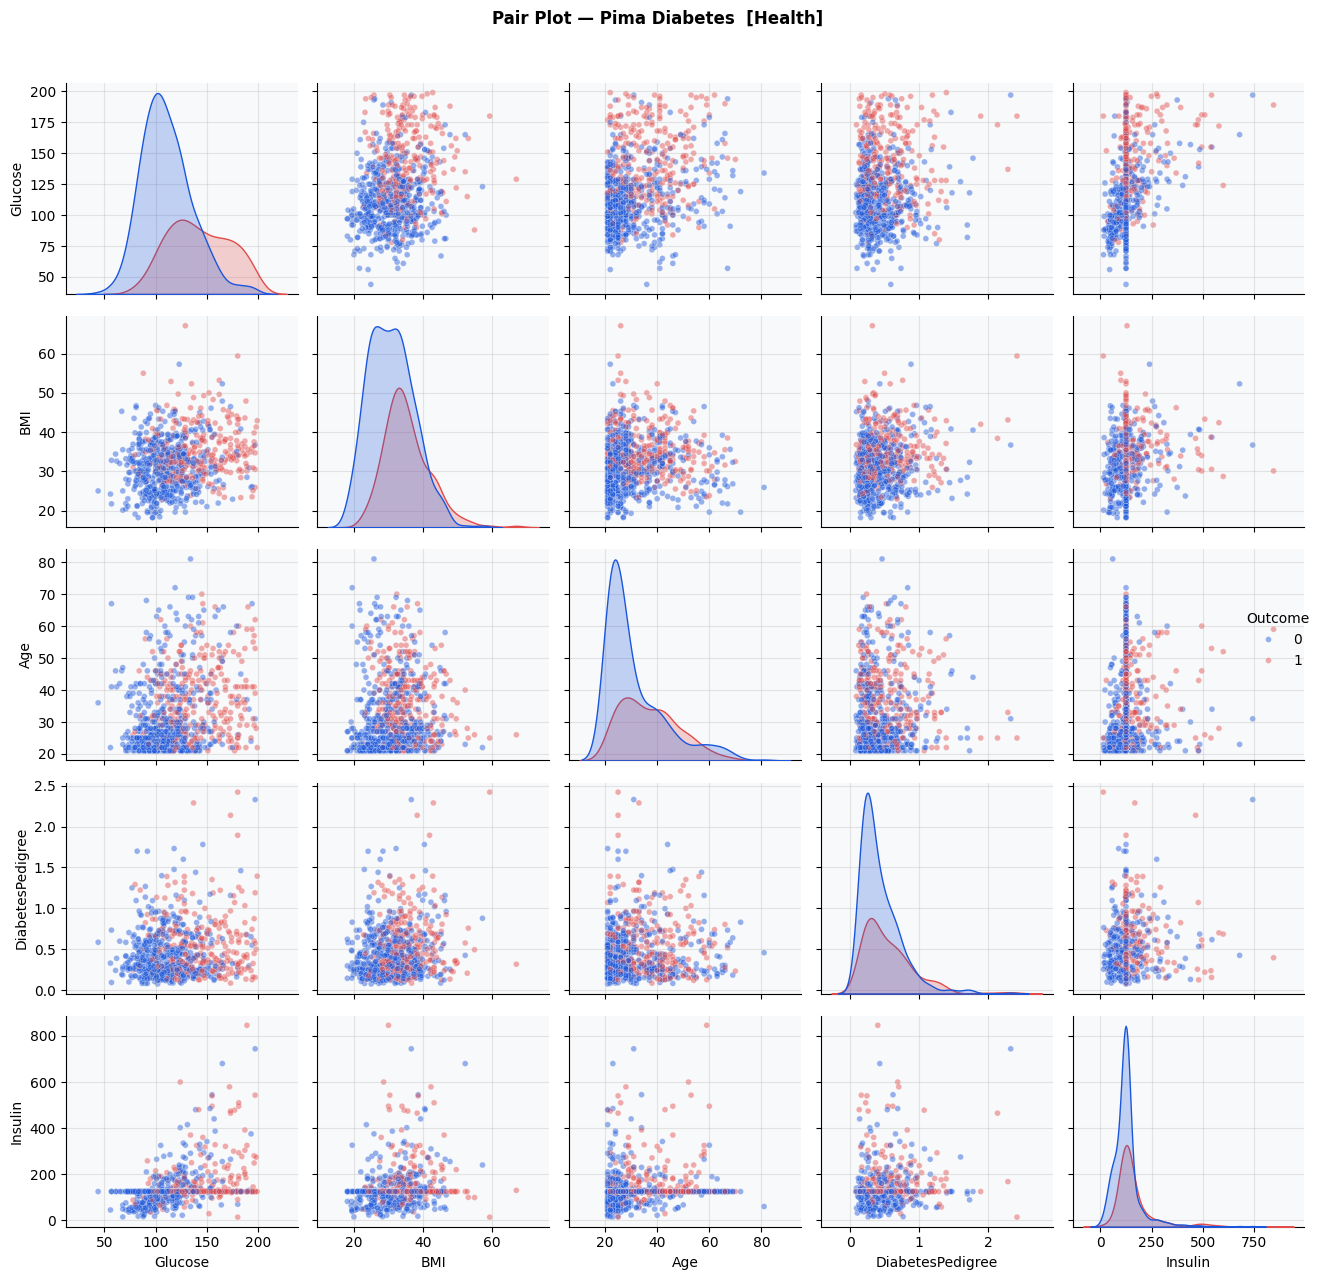

In [12]:
import pandas as pd
import numpy as np # Add numpy import for np.nan

# ============================================================
# DATASET 1 — HEALTH
# Pima Indians Diabetes (UCI / Kaggle)
# 768 records | 8 features | Binary target: Outcome (diabetes)
# ============================================================
# Domain notes:
# - Zero values in physiological columns are impossible and represent missing data
# - High class imbalance: ~35% positive (diabetes=1)
# ============================================================

COLS = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome'
]

pima = pd.read_csv(
    'https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv',
    header=0 # Correctly read the first row as header
)
# Rename 'DiabetesPedigreeFunction' to 'DiabetesPedigree' to match COLS
pima.rename(columns={'DiabetesPedigreeFunction': 'DiabetesPedigree'}, inplace=True)

# Replace physiologically impossible zero values with NaN before analysis
ZERO_AS_NAN = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
pima[ZERO_AS_NAN] = pima[ZERO_AS_NAN].replace(0, np.nan)

print(f"Loaded: {pima.shape[0]} rows x {pima.shape[1]} columns")
print(f"Class distribution:\n{pima['Outcome'].value_counts().to_string()}")

eda_health = EDAAnalyser(pima, name='Pima Diabetes  [Health]', target='Outcome')

eda_health.overview()
eda_health.missing_report()
eda_health.impute(strategy='median')
eda_health.outlier_iqr(cols=['Glucose', 'BloodPressure', 'BMI', 'Insulin', 'Age'])
eda_health.outlier_zscore()
eda_health.distribution()
eda_health.skewness_report()
eda_health.correlation_heatmap()
eda_health.vif_report()
eda_health.pairplot(
    cols=['Glucose', 'BMI', 'Age', 'DiabetesPedigree', 'Insulin'],
    hue='Outcome'
)

---
## Dataset 2 — Financial
### Loan Application Approval

**Source:** Synthetically generated with realistic distributions  
**Task:** Predict loan approval outcome  
**Key challenge:** Right-skewed income/loan distributions; multicollinearity between financial ratios


Generated: 1000 rows x 8 columns
Approval rate: 35.2%

  EDAAnalyser  —  Loan Applications  [Financial]
  Rows       : 1000
  Columns    : 8
  Numeric    : ['income', 'loan_amount', 'credit_score', 'employ_years', 'debt_to_income', 'credit_lines', 'prior_defaults']
  Categorical: []
  Target     : loan_approved

--- Overview: Loan Applications  [Financial] ---
                  dtype  nulls  null_pct
income          float64      0       0.0
loan_amount     float64      0       0.0
credit_score    float64     50       5.0
employ_years    float64     30       3.0
debt_to_income  float64      0       0.0
credit_lines    float64      0       0.0
prior_defaults  float64      0       0.0
loan_approved     int64      0       0.0

Descriptive Statistics (numeric):
                 count       mean        std       min       25%       50%       75%        max
income          1000.0  55930.813  30255.166  9695.000  35461.75  49644.50  67776.75  336504.00
loan_amount     1000.0  27441.522  17684.

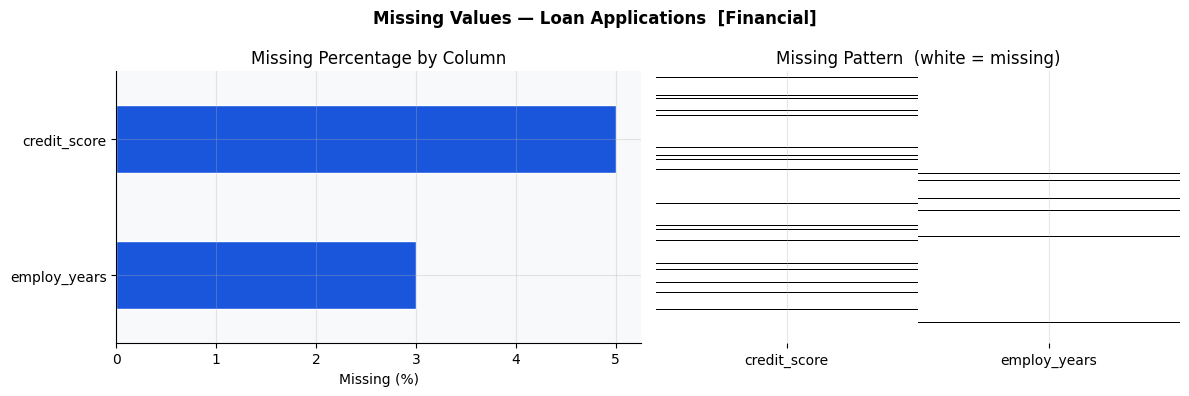


--- Imputation (median): Loan Applications  [Financial] ---
  credit_score               fill value = 679.0
  employ_years               fill value = 3.3

--- Outlier Detection (IQR): Loan Applications  [Financial] ---
                      Q1        Q3       IQR  lower_fence  upper_fence  outliers  outlier_pct
feature                                                                                      
income          35461.75  67776.75  32315.00    -13010.75    116249.25        48          4.8
loan_amount     15310.00  34109.50  18799.50    -12889.25     62308.75        44          4.4
credit_score      633.00    725.25     92.25       494.62       863.62         7          0.7
debt_to_income      0.95      0.95      0.00         0.95         0.95        13          1.3


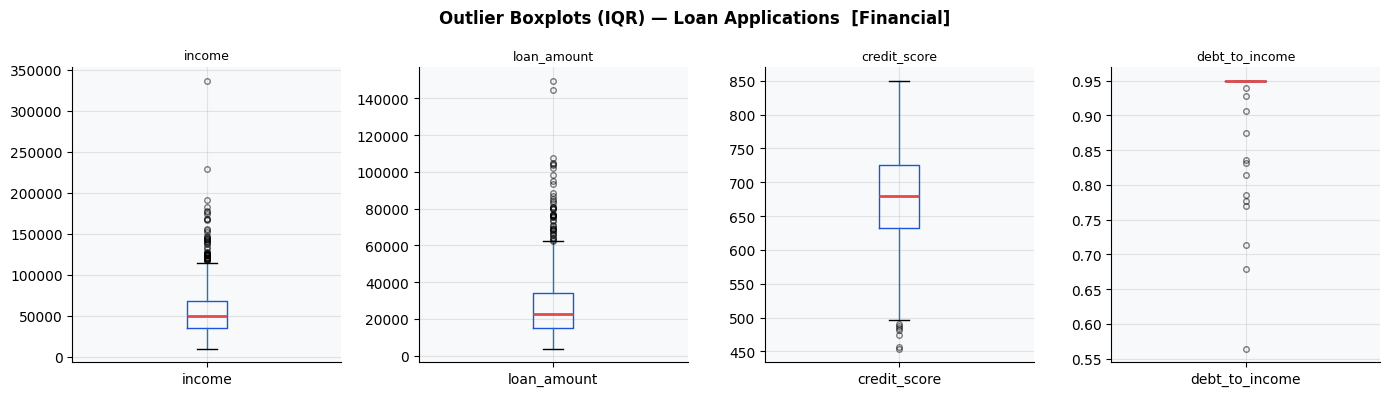


--- Outlier Detection (Z-score, |z|>3.0): Loan Applications  [Financial] ---
  income                   : 13 flagged  (1.30%)
  loan_amount              : 17 flagged  (1.70%)
  credit_score             : 2 flagged  (0.20%)


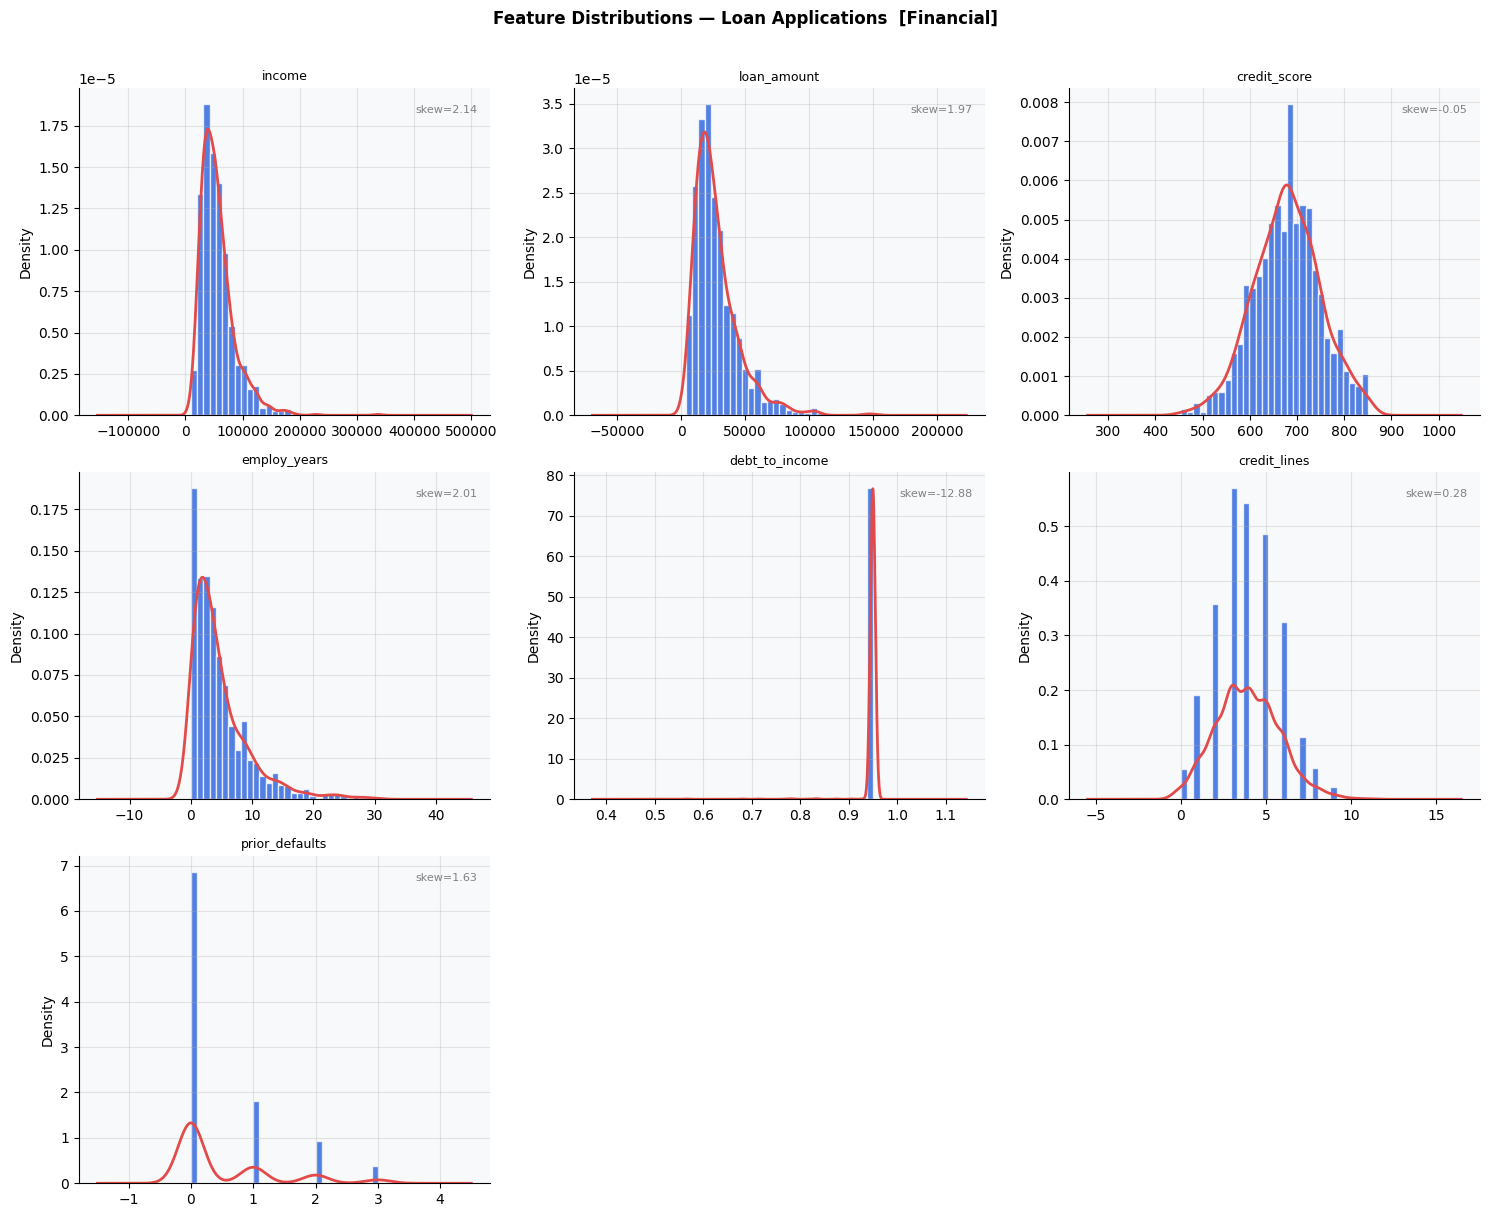


--- Skewness Report: Loan Applications  [Financial] ---
                skewness                            interpretation
debt_to_income   -12.881  high skew  (consider log/sqrt transform)
income             2.138  high skew  (consider log/sqrt transform)
employ_years       2.006  high skew  (consider log/sqrt transform)
loan_amount        1.972  high skew  (consider log/sqrt transform)
prior_defaults     1.627  high skew  (consider log/sqrt transform)
credit_lines       0.280                                 symmetric
credit_score      -0.054                                 symmetric


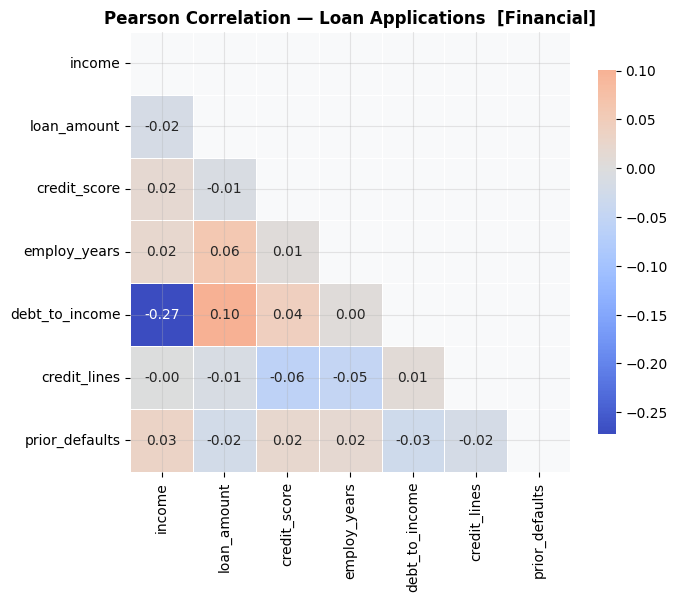


--- VIF Analysis: Loan Applications  [Financial] ---
                   VIF                 status
feature                                      
debt_to_income  104.05  HIGH — multicollinear
credit_score     92.62  HIGH — multicollinear
credit_lines      5.60               moderate
income            4.36                     OK
loan_amount       3.45                     OK
employ_years      2.00                     OK
prior_defaults    1.35                     OK


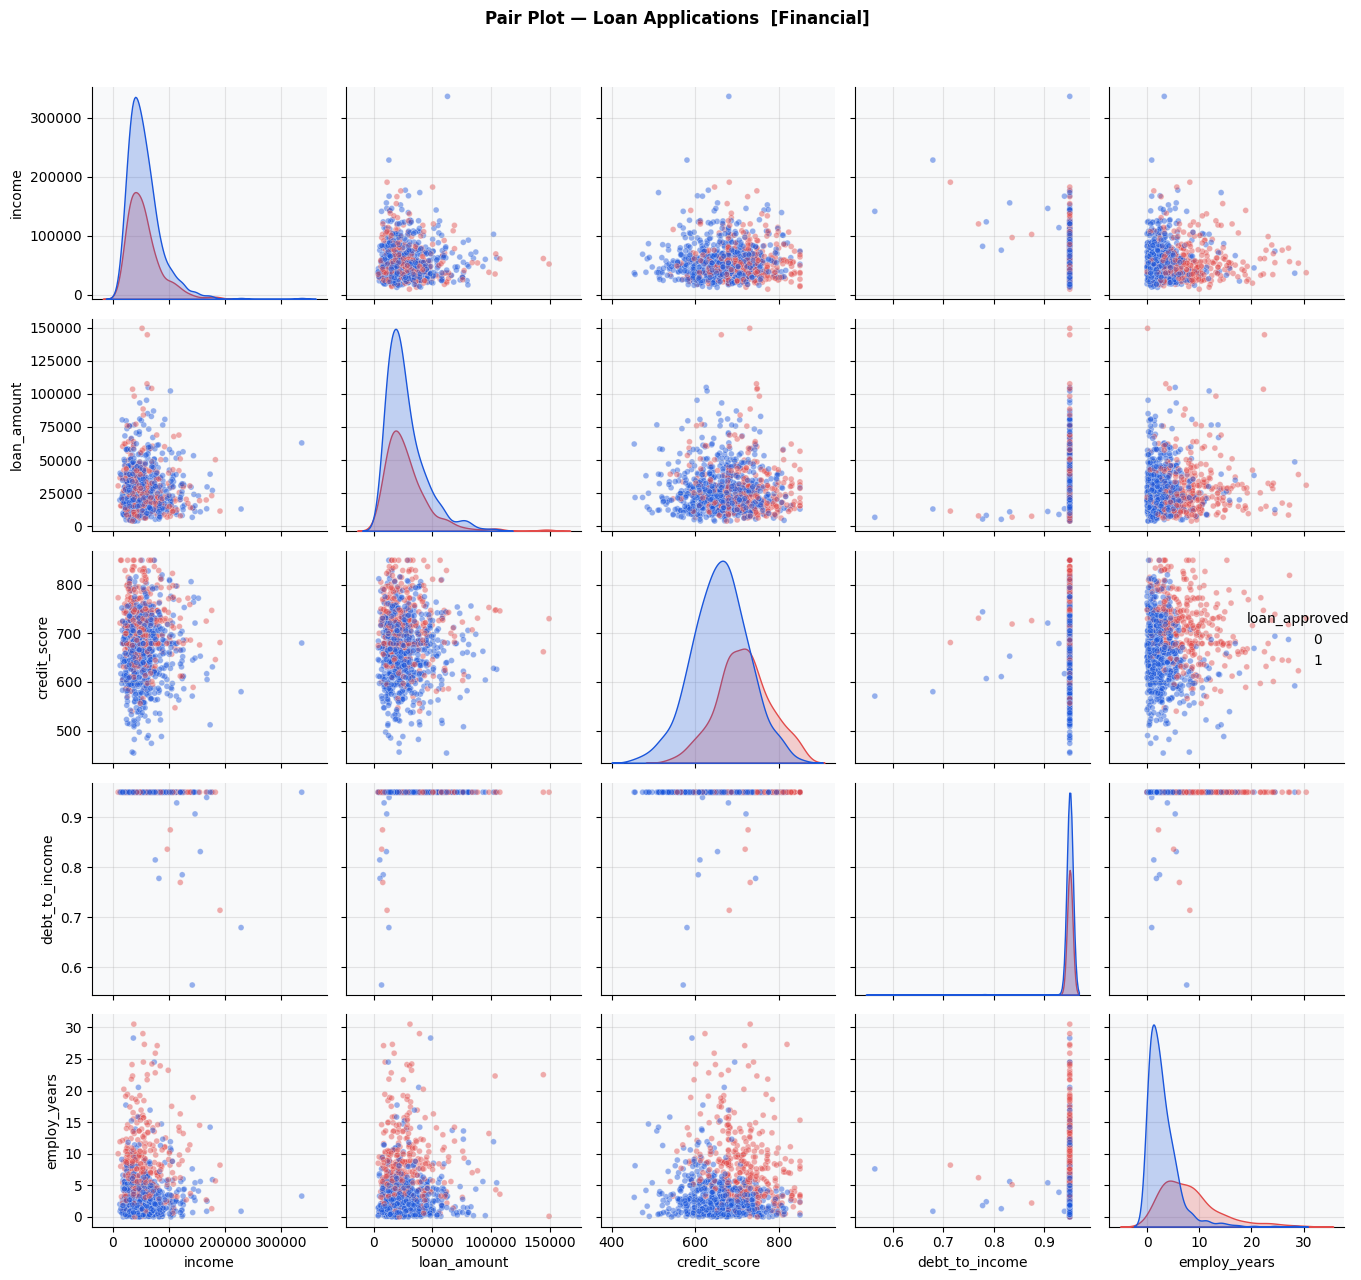

In [13]:
# ============================================================
# DATASET 2 — FINANCIAL
# Synthetic Loan Application Dataset
# 1,000 records | 7 features | Binary target: loan_approved
# ============================================================
# Generation rationale:
# - Income: log-normal (realistic salary distribution)
# - Loan amount: log-normal (right-skewed borrowing behaviour)
# - Credit score: normal (680 mean, clipped to valid 300-850 range)
# - Approval logic: weighted combination of credit, DTI, employment, defaults
# ============================================================

np.random.seed(42)
N = 1000

income        = np.random.lognormal(mean=10.8, sigma=0.5, size=N)
loan_amount   = np.random.lognormal(mean=10.0, sigma=0.6, size=N)
credit_score  = np.random.normal(680, 75, N).clip(300, 850)
employ_years  = np.random.exponential(scale=5, size=N).clip(0, 35).round(1)
debt_to_inc   = np.clip(loan_amount / income * 12, 0.05, 0.95)
credit_lines  = np.random.poisson(4, N).clip(0, 15).astype(float)
prior_def     = np.random.choice([0, 1, 2, 3], N, p=[0.70, 0.18, 0.08, 0.04]).astype(float)

# Approval score: higher credit, lower DTI, more experience, fewer defaults
approval_score = (
    (credit_score - 300) / 550 * 0.40
    + (1 - debt_to_inc)        * 0.30
    + np.clip(employ_years / 10, 0, 1) * 0.20
    + (1 - prior_def / 3)      * 0.10
)
approved = (approval_score + np.random.normal(0, 0.05, N) > 0.50).astype(int)

loan_df = pd.DataFrame({
    'income':         income.round(0),
    'loan_amount':    loan_amount.round(0),
    'credit_score':   credit_score.round(0),
    'employ_years':   employ_years,
    'debt_to_income': debt_to_inc.round(4),
    'credit_lines':   credit_lines,
    'prior_defaults': prior_def,
    'loan_approved':  approved,
})

# Introduce realistic missing data (~5% in credit_score, ~3% in employ_years)
loan_df.loc[np.random.choice(N, 50, replace=False), 'credit_score']  = np.nan
loan_df.loc[np.random.choice(N, 30, replace=False), 'employ_years']  = np.nan

print(f"Generated: {loan_df.shape[0]} rows x {loan_df.shape[1]} columns")
print(f"Approval rate: {loan_df['loan_approved'].mean() * 100:.1f}%")

eda_fin = EDAAnalyser(loan_df, name='Loan Applications  [Financial]', target='loan_approved')

eda_fin.overview()
eda_fin.missing_report()
eda_fin.impute(strategy='median')
eda_fin.outlier_iqr(cols=['income', 'loan_amount', 'credit_score', 'debt_to_income'])
eda_fin.outlier_zscore(cols=['income', 'loan_amount', 'credit_score'])
eda_fin.distribution()
eda_fin.skewness_report()
eda_fin.correlation_heatmap()
eda_fin.vif_report()
eda_fin.pairplot(
    cols=['income', 'loan_amount', 'credit_score', 'debt_to_income', 'employ_years'],
    hue='loan_approved'
)


---
## Dataset 3 — Retail
### Transaction Records

**Source:** Synthetically generated with injected outliers  
**Task:** Predict product return likelihood  
**Key challenge:** Revenue is algebraically derived from price × quantity × (1−discount) — excluded from VIF to avoid artificial multicollinearity


Generated: 900 rows x 9 columns
Return rate: 3.9%
Category distribution:
category
Clothing       228
Electronics    217
Food           190
Home           166
Sports          99

  EDAAnalyser  —  Retail Transactions  [Retail]
  Rows       : 900
  Columns    : 9
  Numeric    : ['unit_price', 'quantity', 'discount', 'revenue', 'customer_age', 'days_to_ship']
  Categorical: ['category', 'region']
  Target     : return_flag

--- Overview: Retail Transactions  [Retail] ---
                dtype  nulls  null_pct
unit_price    float64      0      0.00
quantity      float64      0      0.00
discount      float64     55      6.11
revenue       float64      0      0.00
customer_age  float64     28      3.11
days_to_ship  float64      0      0.00
return_flag     int64      0      0.00
category       object      0      0.00
region         object      0      0.00

Descriptive Statistics (numeric):
              count     mean      std    min     25%     50%      75%      max
unit_price    900.0   4

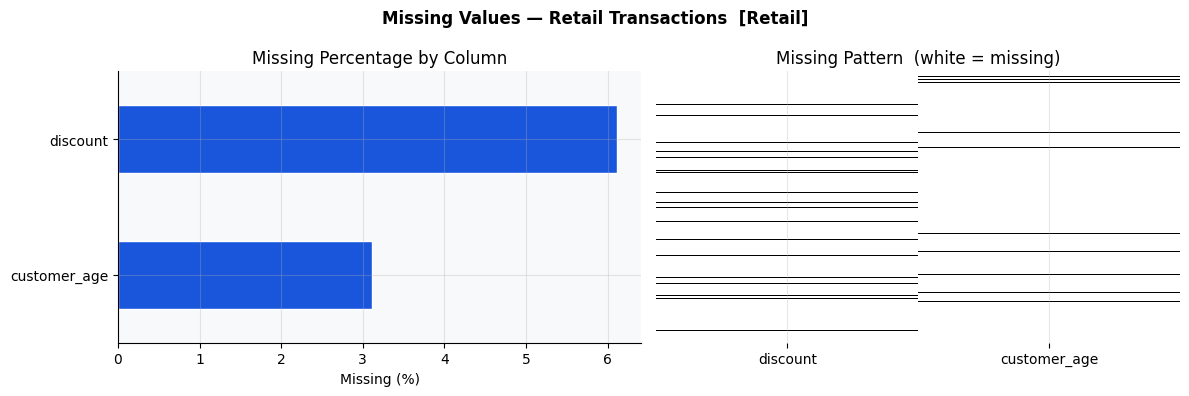


--- Imputation (median): Retail Transactions  [Retail] ---
  discount                   fill value = 0.05
  customer_age               fill value = 38.0

--- Outlier Detection (IQR): Retail Transactions  [Retail] ---
               Q1      Q3    IQR  lower_fence  upper_fence  outliers  outlier_pct
feature                                                                          
unit_price  19.91   55.75  35.84       -33.85       109.52        52         5.78
revenue     33.57  119.18  85.60       -94.83       247.59        66         7.33


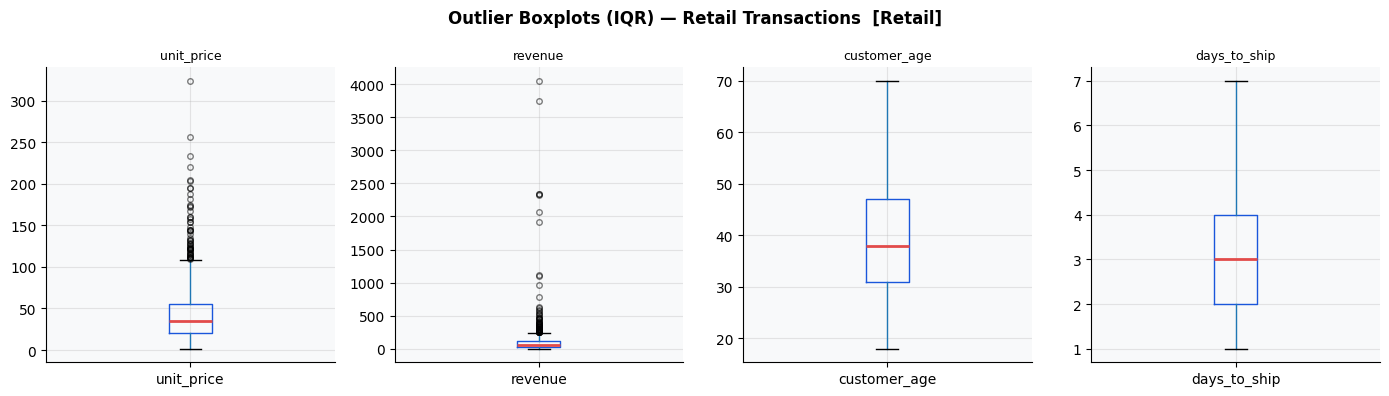


--- Outlier Detection (Z-score, |z|>3.0): Retail Transactions  [Retail] ---
  revenue                  : 10 flagged  (1.11%)
  unit_price               : 19 flagged  (2.11%)


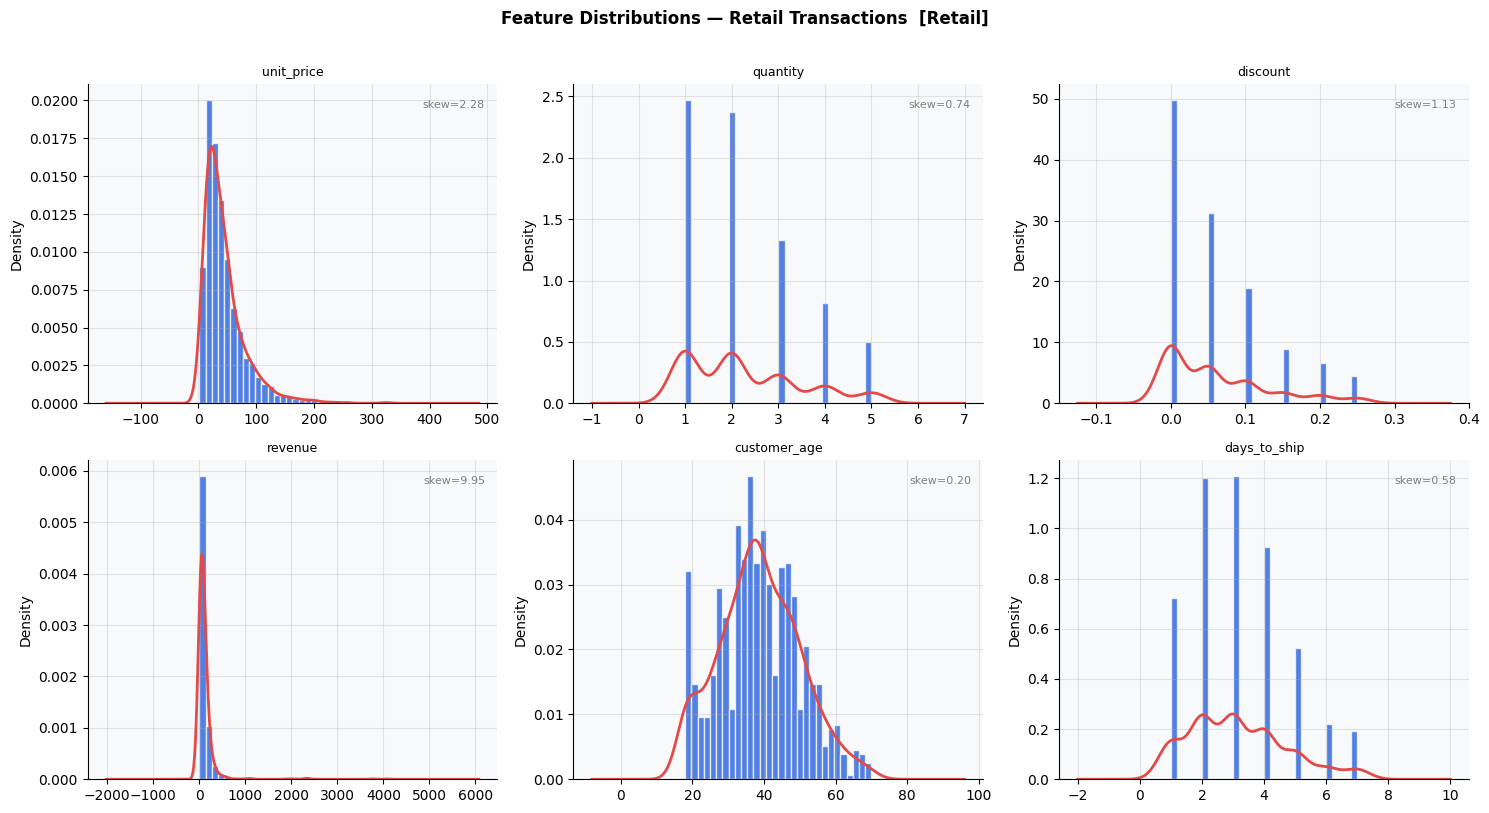


--- Skewness Report: Retail Transactions  [Retail] ---
              skewness                            interpretation
revenue          9.951  high skew  (consider log/sqrt transform)
unit_price       2.279  high skew  (consider log/sqrt transform)
discount         1.133  high skew  (consider log/sqrt transform)
quantity         0.744                             moderate skew
days_to_ship     0.583                             moderate skew
customer_age     0.195                                 symmetric


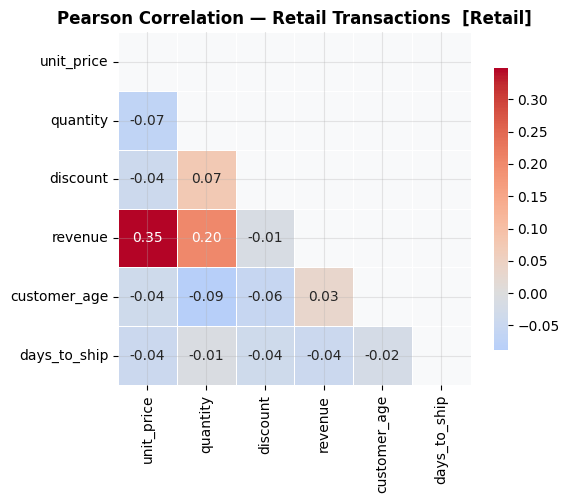


--- VIF Analysis: Retail Transactions  [Retail] ---
               VIF    status
feature                     
customer_age  5.80  moderate
days_to_ship  4.13        OK
quantity      3.68        OK
unit_price    2.25        OK
discount      1.70        OK


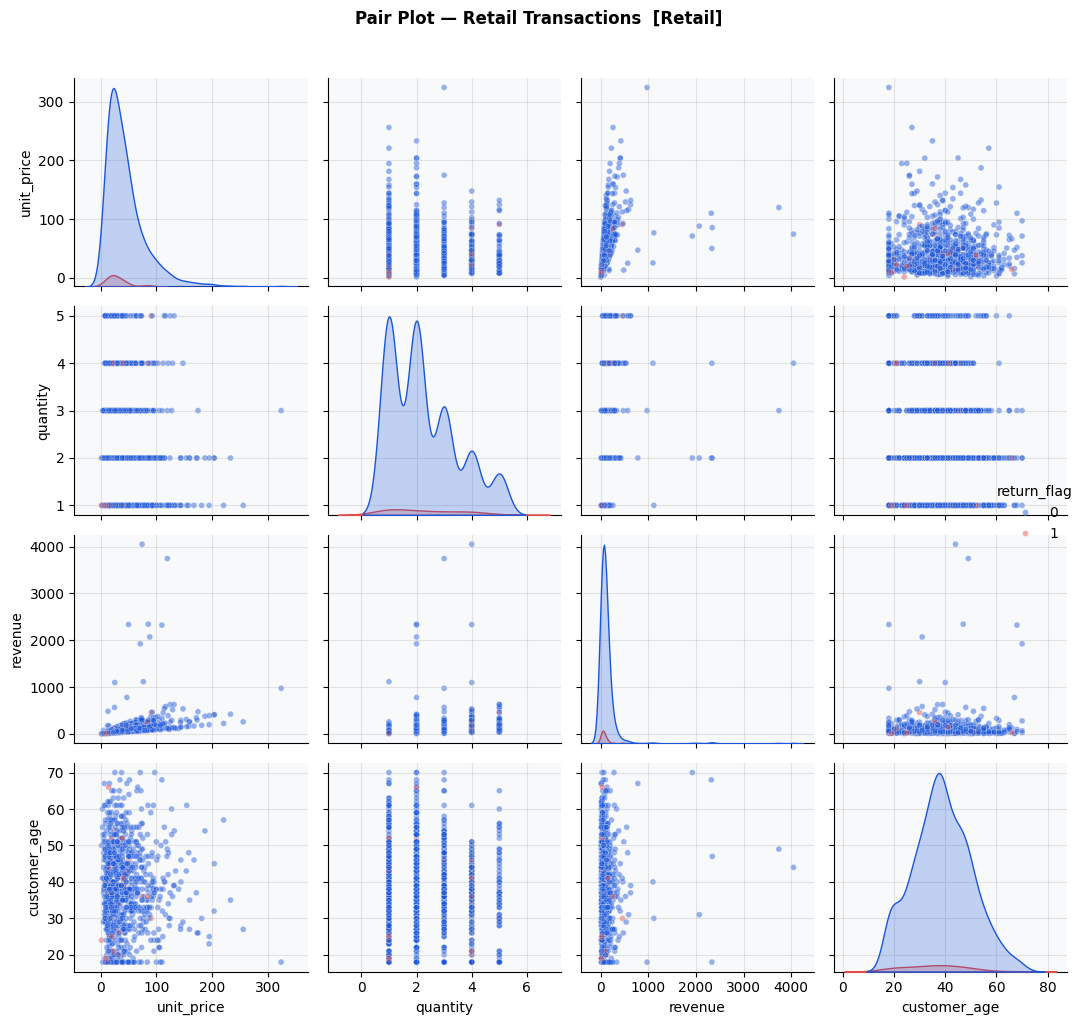

In [14]:
# ============================================================
# DATASET 3 — RETAIL
# Synthetic Retail Transaction Dataset
# 900 records | 6 numeric features | Target: return_flag
# ============================================================
# Generation rationale:
# - unit_price: log-normal (most items cheap, few expensive)
# - revenue: derived from price * quantity * (1 - discount)
# - 15 synthetic outlier transactions to demonstrate detection
# - VIF analysis EXCLUDES revenue (derived column = perfect multicollinearity)
# ============================================================

np.random.seed(123)
N = 900

category   = np.random.choice(
    ['Electronics', 'Clothing', 'Food', 'Home', 'Sports'], N,
    p=[0.25, 0.25, 0.20, 0.20, 0.10]
)
region     = np.random.choice(['North', 'South', 'East', 'West'], N)
unit_price = np.random.lognormal(mean=3.5, sigma=0.8, size=N).round(2)
quantity   = np.random.choice([1, 2, 3, 4, 5], N, p=[0.35, 0.30, 0.18, 0.10, 0.07])
discount   = np.random.choice(
    [0.0, 0.05, 0.10, 0.15, 0.20, 0.25], N,
    p=[0.45, 0.20, 0.15, 0.10, 0.06, 0.04]
)
cust_age   = np.random.normal(38, 12, N).clip(18, 70).round(0)
days_ship  = np.random.choice([1, 2, 3, 4, 5, 6, 7], N,
                               p=[0.15, 0.25, 0.25, 0.15, 0.10, 0.06, 0.04])
revenue    = (unit_price * quantity * (1 - discount)).round(2)

# Inject 15 outlier transactions (bulk/wholesale orders)
out_idx          = np.random.choice(N, 15, replace=False)
revenue[out_idx] = (revenue[out_idx] * np.random.uniform(8, 15, 15)).round(2)

# Return probability increases slightly with transaction value
return_prob  = 0.04 + 0.14 * (revenue / revenue.max())
return_flag  = (np.random.uniform(0, 1, N) < return_prob).astype(int)

retail_df = pd.DataFrame({
    'unit_price':   unit_price,
    'quantity':     quantity.astype(float),
    'discount':     discount,
    'revenue':      revenue,
    'customer_age': cust_age,
    'days_to_ship': days_ship.astype(float),
    'return_flag':  return_flag,
    'category':     category,
    'region':       region,
})

# Introduce missing values (~6% discount, ~3% customer_age)
retail_df.loc[np.random.choice(N, 55, replace=False), 'discount']     = np.nan
retail_df.loc[np.random.choice(N, 28, replace=False), 'customer_age'] = np.nan

print(f"Generated: {retail_df.shape[0]} rows x {retail_df.shape[1]} columns")
print(f"Return rate: {retail_df['return_flag'].mean() * 100:.1f}%")
print(f"Category distribution:\n{retail_df['category'].value_counts().to_string()}")

eda_retail = EDAAnalyser(retail_df, name='Retail Transactions  [Retail]', target='return_flag')

eda_retail.overview()
eda_retail.missing_report()
eda_retail.impute(strategy='median')
eda_retail.outlier_iqr(cols=['unit_price', 'revenue', 'customer_age', 'days_to_ship'])
eda_retail.outlier_zscore(cols=['revenue', 'unit_price'])
eda_retail.distribution()
eda_retail.skewness_report()
eda_retail.correlation_heatmap()

# VIF excludes 'revenue' — it is algebraically derived from unit_price, quantity,
# and discount, which would produce artificially inflated VIF scores.
eda_retail.vif_report(cols=['unit_price', 'quantity', 'discount',
                            'customer_age', 'days_to_ship'])

eda_retail.pairplot(
    cols=['unit_price', 'quantity', 'revenue', 'customer_age'],
    hue='return_flag'
)


---
## Summary

| Dataset | Rows | Missing | Outliers (IQR) | High Skew Features | High VIF |
|---------|------|---------|----------------|-------------------|----------|
| Pima Diabetes | 768 | Glucose, Insulin, BMI, SkinThickness, BP | Insulin, BMI | Insulin, DiabetesPedigree | Low |
| Loan Applications | 1,000 | credit_score, employ_years | income, loan_amount | income, loan_amount | debt_to_income |
| Retail Transactions | 900 | discount, customer_age | revenue (injected outliers) | revenue, unit_price | revenue excluded |

**Reusable pipeline:** All three datasets processed via the same `EDAAnalyser` class — demonstrating a consistent, domain-agnostic approach to EDA.
